# Problem 2.1 — Interactive arbitrage search with all calls and all puts

This notebook implements an interactive arbitrage-search workflow for a one-period option market. The user runs the notebook, selects a ticker, chooses an expiration date, specifies a transaction-cost perturbation, and then solves a mixed-integer linear program that searches for an arbitrage portfolio.

The terminal stock price is denoted by $x=S_T\in\mathbb{R}_+$. A portfolio produces a terminal profit function

$$
\Pi(x).
$$

The first optimization problem searches for an arbitrage in the standard sense:

$$
\Pi(x) \geq 0 \quad \text{for every } x\geq 0,
$$

and, if possible,

$$
\Pi(x)>0 \quad \text{for at least one feasible terminal stock price } x.
$$

The notebook treats all Yahoo calls and all Yahoo puts as independent traded instruments. Calls and puts are **not** matched by common strike, and no common-strike filtering is imposed. Purchases are executed at ask prices and sales are executed at bid prices.

After the standard arbitrage test, the notebook contains an additional interval-focused optimization cell. For a user-selected interval

$$
A=(a,b),
$$

that cell attempts to construct a non-negative portfolio whose terminal profit is positive at the endpoints $a,b$ and at every quoted option strike $K_i\in(a,b)$. Because option portfolios have piecewise affine payoff functions with breakpoints at the strikes, positivity at all such breakpoints certifies positivity on the whole interval, up to the numerical tolerance of the solver.

This notebook is formatted for GitHub rendering. Mathematical displays use `$$ ... $$` rather than bracket-style display math, so the explanation cells remain readable even after the notebook has been run and outputs are visible below the code cells.

## Cell 1 — Install the required packages

This cell installs the Python packages required by the notebook. The mathematical optimization model is solved with SciPy's MILP interface, while market data are downloaded from Yahoo Finance.

The optimization variables represent long and short positions in calls, puts, the stock, and the bank account. For a terminal stock price $x$, the elementary payoff functions are

$$
(x-K)^+ = \max(x-K,0)
$$

for a call option, and

$$
(K-x)^+ = \max(K-x,0)
$$

for a put option. The package installation cell does not build the model; it only ensures that the numerical and plotting libraries are available before the later cells are run.

If the notebook has already been run and uploaded to GitHub with outputs, this markdown explanation still appears above the installation command, keeping the notebook readable as a standalone document.

In [1]:
# Install the external packages required by the notebook.
# This cell is intentionally small so that it is easy to re-run in Colab.
%pip -q install yfinance prettytable scipy pandas matplotlib

## Cell 2 — Load the full arbitrage-search implementation

This cell defines the full implementation used by the notebook. The core object is the terminal profit function

$$
\Pi(x)
=
\sum_j q_j^C (x-K_j^C)^+
-
\sum_j s_j^C (x-K_j^C)^+
+
\sum_k q_k^P (K_k^P-x)^+
-
\sum_k s_k^P (K_k^P-x)^+
+
\Delta^+x-
\Delta^-x
+B(1+r)^T
-V.
$$

Here:

- $q_j^C$ and $s_j^C$ are long and short call quantities,
- $q_k^P$ and $s_k^P$ are long and short put quantities,
- $\Delta^+$ and $\Delta^-$ are long and short stock quantities,
- $B$ is the bank-account position,
- $V$ is the initial capital, usually set to $0$ for a zero-cost arbitrage search,
- $(1+r)^T$ is the bank-account growth factor.

The initial budget constraint is imposed using bid-ask execution:

$$
\text{cash outflow from purchases}
-
\text{cash inflow from sales}
+B
=V.
$$

The standard arbitrage test is formulated as a MILP because option quantities are integer-valued while stock, bank, and auxiliary variables may be continuous. Since $\Pi$ is piecewise affine in $x$, global non-negativity on $\mathbb{R}_+$ is checked at all breakpoints and at a sufficiently large right-tail point, together with a non-negative tail-slope condition.

All comments and docstrings in this implementation are written in English so that the notebook can be published as a GitHub-facing technical artifact.

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Problem 2.1 - Arbitrage detection with all Yahoo calls and all Yahoo puts.

This Colab-ready script follows the output style of the uploaded
FindingArbitrage.ipynb notebook:
- input summary,
- portfolio table,
- option-position table,
- arbitrage conclusion,
- payoff/profit plot.

Important modelling choices
---------------------------
1. Calls and puts are treated as independent instruments.
   There is no call-put matching by strike and no common-strike filtering.
   If Yahoo returns 80 calls and 74 puts, the MILP receives 154 independent
   option instruments.

2. The model uses bid-ask execution:
   - buying an option/share costs the ask,
   - selling an option/share receives the bid.

3. The user supplies an external transaction-cost perturbation.
   The perturbation widens the spread conservatively:
   - effective ask = ask * (1 + perturbation_percent / 100) + absolute_perturbation,
   - effective bid = max(0, bid * (1 - perturbation_percent / 100) - absolute_perturbation).

4. The main Colab workflow is interactive.
   The user runs run_interactive_analysis(), types the ticker, sees all
   available expiration dates, chooses one by number or exact date, and then
   types the transaction-cost perturbation.

Requirements
------------
numpy, pandas, scipy, yfinance, prettytable, matplotlib
"""

from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime, timezone
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

try:
    import yfinance as yf
except Exception:
    yf = None

from scipy.optimize import Bounds, LinearConstraint, milp

try:
    from prettytable import PrettyTable
except Exception:
    PrettyTable = None


# =============================================================================
# User configuration
# =============================================================================

@dataclass
class UserConfig:
    """External inputs controlled by the user."""

    ticker: str
    expiration_date: str
    transaction_cost_perturbation_percent: float

    # If True, lastPrice is used as both bid and ask before perturbation.
    # If False, Yahoo bid and ask fields are used.
    use_last_price: bool = False

    # Annual risk-free rate in percent. Example: 4.0 means 4%.
    risk_free_rate_percent: float = 4.0

    # Initial capital V. For a zero-cost arbitrage search, use V=0.
    initial_capital: float = 0.0

    # Optional absolute spread widening in price units.
    absolute_perturbation: float = 0.0

    # Effective stock spread around spot before transaction-cost perturbation.
    # Example: 0.10 means an initial 0.10% full stock spread around spot.
    stock_spread_percent: float = 0.0

    # Total option-position limits.
    max_total_call_options_to_buy: int = 40
    max_total_call_options_to_sell: int = 40
    max_total_put_options_to_buy: int = 40
    max_total_put_options_to_sell: int = 40

    # Per-option limits. Each Yahoo option row is a separate instrument.
    max_call_options_to_buy_per_contract: int = 2
    max_call_options_to_sell_per_contract: int = 2
    max_put_options_to_buy_per_contract: int = 2
    max_put_options_to_sell_per_contract: int = 2

    # Stock buy/sell limits.
    max_shares_to_buy: float = 100.0
    max_shares_to_sell: float = 100.0

    # Bank-account bounds.
    max_deposit_limit: float = 1_000_000.0
    max_borrow_limit: float = 1_000_000.0

    # Numerical and plotting settings.
    solver_tolerance: float = 1e-8
    plot_points: int = 800
    high_price_multiplier: float = 3.0


# =============================================================================
# Expiration-date discovery and validation
# =============================================================================

def _require_yfinance() -> None:
    """Raise a clear error if yfinance is not available."""
    if yf is None:
        raise RuntimeError(
            "yfinance is not available. In Colab, run: "
            "!pip -q install yfinance prettytable scipy pandas matplotlib"
        )


def available_expirations(ticker: str) -> List[str]:
    """
    Return all option expiration dates currently listed by Yahoo Finance.

    The returned dates are strings in the format used by yfinance, for example
    '2026-06-19'.
    """
    _require_yfinance()
    clean_ticker = ticker.upper().strip()
    if not clean_ticker:
        raise ValueError("ticker must be a non-empty string.")

    stock = yf.Ticker(clean_ticker)
    dates = list(stock.options or [])
    if not dates:
        raise RuntimeError(
            f"No option expiration dates were returned for ticker {clean_ticker!r}. "
            "Check the ticker symbol or try again later."
        )
    return dates


def show_available_expiration_dates(ticker: str) -> List[str]:
    """
    Print a numbered list of available option expiration dates.

    The user should copy one of the printed dates into EXPIRATION_DATE.
    """
    dates = available_expirations(ticker)

    print("\n" + "=" * 78)
    print(f"Available expiration dates for {ticker.upper().strip()}")
    print("=" * 78)

    table = _make_table(["#", "Expiration date"])
    if table is not None:
        for i, d in enumerate(dates):
            table.add_row([i, d])
        print(table)
    else:
        display(pd.DataFrame({"#": range(len(dates)), "Expiration date": dates}))

    print("\nChoose one of these dates and set EXPIRATION_DATE in the next cell.")
    return dates


def validate_expiration_date(ticker: str, expiration_date: str, dates: Optional[Sequence[str]] = None) -> None:
    """
    Validate that expiration_date belongs to the available expiration list.

    This avoids silent errors caused by typos or stale dates.
    """
    if dates is None:
        dates = available_expirations(ticker)

    if expiration_date not in dates:
        preview = ", ".join(list(dates)[:20])
        more = " ..." if len(dates) > 20 else ""
        raise ValueError(
            f"Expiration date {expiration_date!r} is not available for {ticker.upper().strip()}.\n"
            f"Available dates include: {preview}{more}"
        )


# =============================================================================
# Data acquisition
# =============================================================================

def year_fraction_to_expiration(expiration_date: str) -> float:
    """
    Compute an ACT/365 year fraction from the current UTC time to expiration.

    For a date without an explicit time, the timestamp is interpreted at
    midnight UTC. The value is floored at zero.
    """
    expiry = pd.to_datetime(expiration_date).to_pydatetime()
    if expiry.tzinfo is None:
        expiry = expiry.replace(tzinfo=timezone.utc)
    now = datetime.now(timezone.utc)
    seconds = max((expiry - now).total_seconds(), 0.0)
    return seconds / (365.0 * 24.0 * 3600.0)


def _clean_option_side(df: pd.DataFrame, side: str, use_last_price: bool) -> pd.DataFrame:
    """
    Keep all valid option rows for one side of the chain.

    No matching against the other option side is performed. The only filtering
    is quote-quality filtering: finite strike, finite ask, finite bid,
    ask > 0, bid >= 0, and ask >= bid.
    """
    if df is None or df.empty:
        return pd.DataFrame(columns=["type", "strike", "lastPrice", "bid", "ask", "raw_bid", "raw_ask"])

    cols = ["strike", "lastPrice", "bid", "ask"]
    out = df.loc[:, [c for c in cols if c in df.columns]].copy()
    for c in cols:
        if c not in out.columns:
            out[c] = np.nan

    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    out["type"] = side

    if use_last_price:
        # lastPrice is used as a frictionless quote before the artificial
        # transaction-cost perturbation is applied.
        out["raw_bid"] = out["lastPrice"]
        out["raw_ask"] = out["lastPrice"]
    else:
        out["raw_bid"] = out["bid"]
        out["raw_ask"] = out["ask"]

    out = out.dropna(subset=["strike", "raw_bid", "raw_ask"])
    out = out.query("strike > 0 and raw_ask > 0 and raw_bid >= 0 and raw_ask >= raw_bid")
    out = out.sort_values("strike").reset_index(drop=True)

    return out[["type", "strike", "lastPrice", "bid", "ask", "raw_bid", "raw_ask"]]


def fetch_option_chain_from_yahoo(
    ticker: str,
    expiration_date: str,
    use_last_price: bool = False,
    known_expirations: Optional[Sequence[str]] = None,
) -> Tuple[float, pd.DataFrame, pd.DataFrame]:
    """
    Download spot, calls, and puts from Yahoo Finance.

    Calls and puts are returned as separate dataframes. They are not merged,
    paired, or filtered by common strike.
    """
    _require_yfinance()

    clean_ticker = ticker.upper().strip()
    validate_expiration_date(clean_ticker, expiration_date, known_expirations)

    stock = yf.Ticker(clean_ticker)

    hist = stock.history(period="5d")
    close = hist.get("Close", pd.Series(dtype=float)).dropna()
    if close.empty:
        raise RuntimeError(f"Unable to fetch a recent spot price for {clean_ticker}.")
    spot = float(close.iloc[-1])

    chain = stock.option_chain(expiration_date)
    calls = _clean_option_side(chain.calls, "call", use_last_price)
    puts = _clean_option_side(chain.puts, "put", use_last_price)

    if calls.empty and puts.empty:
        raise RuntimeError(
            f"Yahoo returned no valid call or put quotes for {clean_ticker} "
            f"at expiration {expiration_date}."
        )

    return spot, calls, puts


# =============================================================================
# Bid-ask spread and transaction-cost perturbation
# =============================================================================

def apply_transaction_cost_perturbation(
    quotes: pd.DataFrame,
    perturbation_percent: float,
    absolute_perturbation: float = 0.0,
) -> pd.DataFrame:
    """
    Widen bid-ask spreads to account for transaction costs.

    The perturbation is conservative:
    - asks are increased,
    - bids are decreased but not allowed to become negative.
    """
    if perturbation_percent < 0:
        raise ValueError("transaction_cost_perturbation_percent must be nonnegative.")
    if absolute_perturbation < 0:
        raise ValueError("absolute_perturbation must be nonnegative.")

    out = quotes.copy()
    pct = float(perturbation_percent) / 100.0

    out["eff_ask"] = out["raw_ask"] * (1.0 + pct) + float(absolute_perturbation)
    out["eff_bid"] = np.maximum(0.0, out["raw_bid"] * (1.0 - pct) - float(absolute_perturbation))

    # Keep only quotes that remain economically meaningful.
    out = out.query("eff_ask > 0 and eff_bid >= 0 and eff_ask >= eff_bid").copy()
    out = out.reset_index(drop=True)
    return out


def effective_stock_bid_ask(
    spot: float,
    stock_spread_percent: float,
    perturbation_percent: float,
) -> Tuple[float, float]:
    """
    Construct effective stock bid and ask prices.

    yfinance usually supplies a recent spot/close price rather than a
    synchronized stock bid/ask pair. We therefore create a symmetric spread
    around spot and then apply the same conservative perturbation.
    """
    if spot <= 0:
        raise ValueError("spot must be positive.")
    if stock_spread_percent < 0:
        raise ValueError("stock_spread_percent must be nonnegative.")
    if perturbation_percent < 0:
        raise ValueError("transaction_cost_perturbation_percent must be nonnegative.")

    half = float(stock_spread_percent) / 200.0
    pct = float(perturbation_percent) / 100.0

    base_bid = float(spot) * (1.0 - half)
    base_ask = float(spot) * (1.0 + half)

    eff_bid = max(0.0, base_bid * (1.0 - pct))
    eff_ask = base_ask * (1.0 + pct)

    if eff_ask < eff_bid:
        raise RuntimeError("Effective stock ask became smaller than effective stock bid.")
    return eff_bid, eff_ask


# =============================================================================
# MILP model
# =============================================================================

def _payoff_row(
    y: float,
    call_strikes: np.ndarray,
    put_strikes: np.ndarray,
    bank_growth: float,
) -> np.ndarray:
    """
    Terminal payoff row for the MILP decision variables.

    Variable order:
    [call_buy(m), call_sell(m),
     put_buy(n), put_sell(n),
     share_buy, share_sell,
     bank, z]

    The actual net stock position is share_buy - share_sell.
    The auxiliary variable z is included with coefficient 1 in the payoff
    constraint but is not part of the real portfolio payoff.
    """
    call_pay = np.maximum(y - call_strikes, 0.0)
    put_pay = np.maximum(put_strikes - y, 0.0)

    return np.concatenate([
        call_pay,                       # long calls
        -call_pay,                      # short calls
        put_pay,                        # long puts
        -put_pay,                       # short puts
        np.array([y], dtype=float),     # long shares
        np.array([-y], dtype=float),    # short shares
        np.array([bank_growth], dtype=float),
        np.array([1.0], dtype=float),   # z
    ])


def build_and_solve_arbitrage_milp(
    spot: float,
    stock_bid: float,
    stock_ask: float,
    calls: pd.DataFrame,
    puts: pd.DataFrame,
    config: UserConfig,
    T: float,
) -> Dict[str, object]:
    """
    Build and solve the MILP arbitrage-search model.

    Every call row and every put row is used independently. The only common
    object is the terminal payoff grid, which consists of zero, all call
    strikes, all put strikes, and a large point used for tail safety.
    """
    call_strikes = calls["strike"].to_numpy(float)
    put_strikes = puts["strike"].to_numpy(float)

    call_ask = calls["eff_ask"].to_numpy(float)
    call_bid = calls["eff_bid"].to_numpy(float)
    put_ask = puts["eff_ask"].to_numpy(float)
    put_bid = puts["eff_bid"].to_numpy(float)

    m = len(call_strikes)
    n = len(put_strikes)

    if m == 0 and n == 0:
        raise RuntimeError("No option instruments remain after quote filtering.")

    r = float(config.risk_free_rate_percent) / 100.0
    bank_growth = (1.0 + r) ** float(T)

    # A portfolio made of calls, puts, stock, and bank account has a
    # piecewise-affine terminal payoff. It is enough to test all breakpoints.
    base_grid = np.unique(np.concatenate([
        np.array([0.0], dtype=float),
        call_strikes,
        put_strikes,
    ]))

    max_reference = max(float(spot), float(base_grid.max()), 1.0)
    S_high = float(config.high_price_multiplier) * max_reference
    grid = np.unique(np.append(base_grid, S_high))

    L = 2 * m + 2 * n + 4
    share_buy_idx = 2 * m + 2 * n
    share_sell_idx = share_buy_idx + 1
    bank_idx = share_sell_idx + 1
    z_idx = bank_idx + 1

    # Payoff constraints:
    # terminal payoff + z >= V at every grid point.
    # Equivalently: -(terminal payoff + z) <= -V.
    payoff_rows = np.vstack([
        -_payoff_row(float(y), call_strikes, put_strikes, bank_growth)
        for y in grid
    ])
    lb_payoff = np.full(len(grid), -np.inf, dtype=float)
    ub_payoff = np.full(len(grid), -float(config.initial_capital), dtype=float)

    # Tail-slope guard for S -> infinity:
    # slope = net shares + long calls - short calls >= 0.
    A_slope = np.zeros(L)
    A_slope[0:m] = 1.0
    A_slope[m:2*m] = -1.0
    A_slope[share_buy_idx] = 1.0
    A_slope[share_sell_idx] = -1.0

    # Initial budget equality:
    # pay asks when buying, receive bids when selling, and use the bank account
    # to make the initial cashflow equal to V.
    A_cost = np.zeros(L)
    A_cost[0:m] = call_ask
    A_cost[m:2*m] = -call_bid
    A_cost[2*m:2*m+n] = put_ask
    A_cost[2*m+n:2*m+2*n] = -put_bid
    A_cost[share_buy_idx] = stock_ask
    A_cost[share_sell_idx] = -stock_bid
    A_cost[bank_idx] = 1.0

    # Total position-limit constraints, matching the original notebook style.
    A_tot_call_buy = np.zeros(L);  A_tot_call_buy[0:m] = 1.0
    A_tot_call_sell = np.zeros(L); A_tot_call_sell[m:2*m] = 1.0
    A_tot_put_buy = np.zeros(L);   A_tot_put_buy[2*m:2*m+n] = 1.0
    A_tot_put_sell = np.zeros(L);  A_tot_put_sell[2*m+n:2*m+2*n] = 1.0

    A = np.vstack([
        payoff_rows,
        A_slope[None, :],
        A_cost[None, :],
        A_tot_call_buy[None, :],
        A_tot_call_sell[None, :],
        A_tot_put_buy[None, :],
        A_tot_put_sell[None, :],
    ])

    lb = np.concatenate([
        lb_payoff,
        np.array([0.0]),                          # slope lower bound
        np.array([float(config.initial_capital)]), # budget equality
        np.full(4, -np.inf),                      # no lower bound on totals
    ])

    ub = np.concatenate([
        ub_payoff,
        np.array([np.inf]),                       # slope upper bound
        np.array([float(config.initial_capital)]), # budget equality
        np.array([
            float(config.max_total_call_options_to_buy),
            float(config.max_total_call_options_to_sell),
            float(config.max_total_put_options_to_buy),
            float(config.max_total_put_options_to_sell),
        ]),
    ])

    constraints = LinearConstraint(A, lb, ub)

    lower = np.zeros(L)
    upper = np.full(L, np.inf)

    # Per-instrument option bounds.
    upper[0:m] = float(config.max_call_options_to_buy_per_contract)
    upper[m:2*m] = float(config.max_call_options_to_sell_per_contract)
    upper[2*m:2*m+n] = float(config.max_put_options_to_buy_per_contract)
    upper[2*m+n:2*m+2*n] = float(config.max_put_options_to_sell_per_contract)

    # Share buy/sell bounds.
    upper[share_buy_idx] = float(config.max_shares_to_buy)
    upper[share_sell_idx] = float(config.max_shares_to_sell)

    # Bank bounds.
    lower[bank_idx] = -float(config.max_borrow_limit)
    upper[bank_idx] = float(config.max_deposit_limit)

    # z is continuous and free.
    lower[z_idx] = -np.inf
    upper[z_idx] = np.inf

    bounds = Bounds(lower, upper)

    # Options are integer quantities. Stock, bank, and z are continuous.
    integrality = np.ones(L, dtype=int)
    integrality[share_buy_idx] = 0
    integrality[share_sell_idx] = 0
    integrality[bank_idx] = 0
    integrality[z_idx] = 0

    # Objective: minimize z. If z < 0, the portfolio has a positive guaranteed
    # payoff buffer of at least -z over the tested payoff grid and tail guard.
    c = np.zeros(L)
    c[z_idx] = 1.0

    res = milp(c=c, constraints=constraints, integrality=integrality, bounds=bounds)

    if res.x is None:
        raise RuntimeError(f"MILP did not return a solution. Status={res.status}, message={res.message}")

    return {
        "solution": res.x,
        "status": res.status,
        "message": res.message,
        "call_strikes": call_strikes,
        "put_strikes": put_strikes,
        "call_ask": call_ask,
        "call_bid": call_bid,
        "put_ask": put_ask,
        "put_bid": put_bid,
        "calls_table": calls,
        "puts_table": puts,
        "bank_growth": bank_growth,
        "grid": grid,
        "S_high": S_high,
        "share_buy_idx": share_buy_idx,
        "share_sell_idx": share_sell_idx,
        "bank_idx": bank_idx,
        "z_idx": z_idx,
        "stock_bid": stock_bid,
        "stock_ask": stock_ask,
        "spot": spot,
        "T": T,
    }


# =============================================================================
# Reporting, tables, and plotting
# =============================================================================

def _make_table(field_names: Sequence[str]):
    """Create a PrettyTable when available; otherwise return None."""
    if PrettyTable is None:
        return None
    return PrettyTable(field_names)


def profit_at_expiry(y: float, result: Dict[str, object], config: UserConfig) -> float:
    """Evaluate the true terminal profit at stock price y, excluding z."""
    x = result["solution"]
    row = _payoff_row(
        float(y),
        result["call_strikes"],
        result["put_strikes"],
        result["bank_growth"],
    )
    return float(np.dot(row[:-1], x[:-1]) - float(config.initial_capital))


def print_quote_summary(
    spot: float,
    stock_bid: float,
    stock_ask: float,
    calls: pd.DataFrame,
    puts: pd.DataFrame,
    config: UserConfig,
    T: float,
) -> None:
    """Print a compact summary of the input quotes used by the model."""
    print("\n" + "=" * 78)
    print("Input summary")
    print("=" * 78)
    print(f"Ticker: {config.ticker.upper().strip()}")
    print(f"Expiration date: {config.expiration_date}")
    print(f"Time to expiry T: {T:.8f} years")
    print(f"Spot: {spot:.6f}")
    print(f"Effective stock bid/ask: {stock_bid:.6f} / {stock_ask:.6f}")
    print(f"Risk-free rate: {config.risk_free_rate_percent:.6f}%")
    print(f"Initial capital V: {config.initial_capital:.6f}")
    print(f"Transaction-cost perturbation: {config.transaction_cost_perturbation_percent:.6f}%")
    print(f"Absolute perturbation: {config.absolute_perturbation:.6f}")
    print(f"Calls used: {len(calls)}")
    print(f"Puts used: {len(puts)}")
    print("Calls and puts are used independently. No common-strike matching is performed.")


def print_portfolio_tables(result: Dict[str, object], config: UserConfig) -> None:
    """Print the same type of tables as in the uploaded notebook."""
    x = result["solution"]
    ticker = config.ticker.upper().strip()

    call_strikes = result["call_strikes"]
    put_strikes = result["put_strikes"]
    call_ask = result["call_ask"]
    call_bid = result["call_bid"]
    put_ask = result["put_ask"]
    put_bid = result["put_bid"]

    m = len(call_strikes)
    n = len(put_strikes)

    share_buy_idx = result["share_buy_idx"]
    share_sell_idx = result["share_sell_idx"]
    bank_idx = result["bank_idx"]

    share_buy = float(x[share_buy_idx])
    share_sell = float(x[share_sell_idx])
    net_shares = share_buy - share_sell
    stock_cashflow = share_buy * float(result["stock_ask"]) - share_sell * float(result["stock_bid"])

    print("\n" + "=" * 78)
    print("Portfolio table")
    print("=" * 78)

    tb = _make_table(["Asset", "Qty/Amount", "Unit/Info", "Initial Cashflow"])
    if tb is not None:
        tb.add_row([
            ticker + " (Net Shares)",
            round(net_shares, 6),
            f"buy@ask={result['stock_ask']:.6f}, sell@bid={result['stock_bid']:.6f}",
            round(stock_cashflow, 6),
        ])
        tb.add_row([
            "Bank account",
            round(float(x[bank_idx]), 6),
            f"g=(1+r)^T={result['bank_growth']:.6f}",
            round(float(x[bank_idx]), 6),
        ])
        print(tb)
    else:
        display(pd.DataFrame([
            {
                "Asset": ticker + " (Net Shares)",
                "Qty/Amount": round(net_shares, 6),
                "Unit/Info": f"buy@ask={result['stock_ask']:.6f}, sell@bid={result['stock_bid']:.6f}",
                "Initial Cashflow": round(stock_cashflow, 6),
            },
            {
                "Asset": "Bank account",
                "Qty/Amount": round(float(x[bank_idx]), 6),
                "Unit/Info": f"g=(1+r)^T={result['bank_growth']:.6f}",
                "Initial Cashflow": round(float(x[bank_idx]), 6),
            },
        ]))

    print("\n" + "=" * 78)
    print("Option-position table")
    print("=" * 78)

    tt = _make_table(["Type", "Strike", "Qty", "Price each", "Initial Cashflow"])
    rows = []

    for i in range(m):
        qty = int(round(x[i]))
        if qty > 0:
            rows.append(["Call (buy)", call_strikes[i], qty, call_ask[i], qty * call_ask[i]])

    for i in range(m):
        j = m + i
        qty = int(round(x[j]))
        if qty > 0:
            rows.append(["Call (sell)", call_strikes[i], qty, call_bid[i], -qty * call_bid[i]])

    for i in range(n):
        j = 2 * m + i
        qty = int(round(x[j]))
        if qty > 0:
            rows.append(["Put (buy)", put_strikes[i], qty, put_ask[i], qty * put_ask[i]])

    for i in range(n):
        j = 2 * m + n + i
        qty = int(round(x[j]))
        if qty > 0:
            rows.append(["Put (sell)", put_strikes[i], qty, put_bid[i], -qty * put_bid[i]])

    total_option_cashflow = float(sum(row[4] for row in rows))

    if tt is not None:
        for row in rows:
            tt.add_row([
                row[0],
                round(float(row[1]), 6),
                row[2],
                round(float(row[3]), 6),
                round(float(row[4]), 6),
            ])
        if rows:
            tt.add_divider()
        tt.add_row(["Total amount", "--", "--", "--", round(total_option_cashflow, 6)])
        print(tt)
    else:
        if rows:
            display(pd.DataFrame(rows, columns=["Type", "Strike", "Qty", "Price each", "Initial Cashflow"]))
        else:
            print("No option positions selected.")
        print("Total option cashflow:", round(total_option_cashflow, 6))

    total_initial_cashflow = (
        total_option_cashflow
        + stock_cashflow
        + float(x[bank_idx])
    )
    print(f"\nTotal initial cashflow, including stock and bank: {total_initial_cashflow:.8f}")


def print_conclusion(result: Dict[str, object], config: UserConfig) -> None:
    """Print the same conclusion logic as the uploaded notebook."""
    x = result["solution"]
    z = float(x[result["z_idx"]])

    baseline_profit = float(config.initial_capital) * (float(result["bank_growth"]) - 1.0)
    tol = float(config.solver_tolerance)

    m = len(result["call_strikes"])
    n = len(result["put_strikes"])

    opt_sum = float(
        np.sum(x[0:m])
        + np.sum(x[m:2*m])
        + np.sum(x[2*m:2*m+n])
        + np.sum(x[2*m+n:2*m+2*n])
    )

    share_buy = float(x[result["share_buy_idx"]])
    share_sell = float(x[result["share_sell_idx"]])
    bank = float(x[result["bank_idx"]])

    pure_bank = (
        share_buy <= tol
        and share_sell <= tol
        and opt_sum <= tol
        and abs(bank - float(config.initial_capital)) <= 1e-6
    )

    print("\n" + "=" * 78)
    print("Arbitrage conclusion")
    print("=" * 78)

    if pure_bank:
        print("[CONCLUSION] All capital deposited in bank.")
        print("Profit at expiry = interest =", round(baseline_profit, 8))
        print("Not an arbitrage.")
        return

    if z > tol:
        print("[CONCLUSION] No portfolio found with guaranteed profit against V.")
        print("Maximum possible loss z =", round(z, 8))
        print("Bank interest baseline =", round(baseline_profit, 8))
    else:
        worst_case_profit = -z
        print("[CONCLUSION] Guaranteed profit (>=) =", round(worst_case_profit, 8))
        print("Bank interest baseline =", round(baseline_profit, 8))
        if worst_case_profit > baseline_profit + 1e-9:
            print("=> Arbitrage against deposit: exceeds interest by", round(worst_case_profit - baseline_profit, 8))
        else:
            print("=> Not arbitrage against deposit: does not exceed interest.")


def plot_profit_function(result: Dict[str, object], config: UserConfig) -> None:
    """Plot terminal profit as a function of the stock price at expiration."""
    y_max = float(max(result["S_high"], result["spot"] * 1.5))
    y_vals = np.linspace(0.0, y_max, int(config.plot_points))
    profits = np.array([profit_at_expiry(y, result, config) for y in y_vals])

    fig = plt.figure(figsize=(10, 6))
    ax = fig.gca()
    ax.plot(y_vals, profits)
    ax.set_xlabel("Stock Price at Expiration")
    ax.set_ylabel("Profit at Expiry")
    ax.set_title("Profit Function with Bank Account, All Calls, and All Puts")
    ax.grid(True)
    ax.axhline(0.0, linewidth=1.5, linestyle="--")
    ax.fill_between(y_vals, profits, 0.0, where=(profits > 0.0), alpha=0.3, label="Profit")
    ax.fill_between(y_vals, profits, 0.0, where=(profits < 0.0), alpha=0.3, label="Loss")
    ax.legend()
    plt.show()


def display_used_quotes(calls: pd.DataFrame, puts: pd.DataFrame, max_rows: int = 20) -> None:
    """
    Display the first rows of the effective quotes used in the model.

    This is optional but useful for verifying that calls and puts were not
    matched by strike.
    """
    cols = ["type", "strike", "raw_bid", "raw_ask", "eff_bid", "eff_ask"]
    all_quotes = pd.concat([calls[cols], puts[cols]], ignore_index=True)
    print(f"Displaying the first {min(max_rows, len(all_quotes))} of {len(all_quotes)} option instruments.")
    display(all_quotes.head(max_rows))


# =============================================================================
# End-to-end runner
# =============================================================================

def build_config_from_external_inputs(
    ticker: str,
    expiration_date: str,
    transaction_cost_perturbation_percent: float,
    **kwargs,
) -> UserConfig:
    """
    Build a UserConfig object from external variables.

    This function is useful in Colab because the user can edit a small cell with
    TICKER, EXPIRATION_DATE, and TRANSACTION_COST_PERTURBATION_PERCENT, then
    build the configuration object from those variables.
    """
    return UserConfig(
        ticker=ticker.upper().strip(),
        expiration_date=str(expiration_date),
        transaction_cost_perturbation_percent=float(transaction_cost_perturbation_percent),
        **kwargs,
    )


def run_analysis(config: UserConfig, known_expirations: Optional[Sequence[str]] = None) -> Dict[str, object]:
    """
    Run the full arbitrage analysis.

    The function assumes the user has already selected a valid expiration date
    from the list produced by show_available_expiration_dates().
    """
    validate_expiration_date(config.ticker, config.expiration_date, known_expirations)

    spot, calls_raw, puts_raw = fetch_option_chain_from_yahoo(
        ticker=config.ticker,
        expiration_date=config.expiration_date,
        use_last_price=config.use_last_price,
        known_expirations=known_expirations,
    )

    T = year_fraction_to_expiration(config.expiration_date)

    calls = apply_transaction_cost_perturbation(
        calls_raw,
        perturbation_percent=config.transaction_cost_perturbation_percent,
        absolute_perturbation=config.absolute_perturbation,
    )
    puts = apply_transaction_cost_perturbation(
        puts_raw,
        perturbation_percent=config.transaction_cost_perturbation_percent,
        absolute_perturbation=config.absolute_perturbation,
    )

    stock_bid, stock_ask = effective_stock_bid_ask(
        spot=spot,
        stock_spread_percent=config.stock_spread_percent,
        perturbation_percent=config.transaction_cost_perturbation_percent,
    )

    print_quote_summary(spot, stock_bid, stock_ask, calls, puts, config, T)

    result = build_and_solve_arbitrage_milp(
        spot=spot,
        stock_bid=stock_bid,
        stock_ask=stock_ask,
        calls=calls,
        puts=puts,
        config=config,
        T=T,
    )

    print_portfolio_tables(result, config)
    print_conclusion(result, config)
    plot_profit_function(result, config)

    result["calls"] = calls
    result["puts"] = puts
    result["config"] = config
    return result



# =============================================================================
# Interactive Colab runner
# =============================================================================

def _read_nonempty_text(prompt: str) -> str:
    """Read a non-empty string from the user."""
    while True:
        value = input(prompt).strip()
        if value:
            return value
        print("Please enter a non-empty value.")


def _read_float(prompt: str, default: Optional[float] = None, minimum: Optional[float] = None) -> float:
    """Read a floating-point value from the user, with optional default/minimum."""
    while True:
        suffix = f" [default: {default}]" if default is not None else ""
        raw = input(prompt + suffix + ": ").strip()
        if raw == "" and default is not None:
            value = float(default)
        else:
            try:
                value = float(raw)
            except ValueError:
                print("Please enter a valid number.")
                continue
        if minimum is not None and value < minimum:
            print(f"Please enter a value >= {minimum}.")
            continue
        return value


def _read_bool(prompt: str, default: bool = False) -> bool:
    """Read a yes/no answer from the user."""
    default_text = "y" if default else "n"
    while True:
        raw = input(f"{prompt} [y/n, default: {default_text}]: ").strip().lower()
        if raw == "":
            return default
        if raw in {"y", "yes"}:
            return True
        if raw in {"n", "no"}:
            return False
        print("Please answer y or n.")


def _choose_expiration_date_interactively(ticker: str, dates: Sequence[str]) -> str:
    """
    Ask the user to choose an expiration date after the dates have been shown.

    The user may type either the numeric index printed in the table or the exact
    expiration-date string.
    """
    if not dates:
        raise ValueError("No expiration dates are available.")

    while True:
        raw = input("Choose expiration date by number or exact YYYY-MM-DD date: ").strip()
        if raw.isdigit():
            idx = int(raw)
            if 0 <= idx < len(dates):
                return str(dates[idx])
            print(f"Please enter a number between 0 and {len(dates) - 1}.")
            continue

        if raw in dates:
            return raw

        print(f"{raw!r} is not one of the available expiration dates for {ticker.upper()}.")


def run_interactive_analysis(
    default_risk_free_rate_percent: float = 4.0,
    default_initial_capital: float = 0.0,
    default_use_last_price: bool = False,
    default_stock_spread_percent: float = 0.0,
    default_absolute_perturbation: float = 0.0,
    ask_advanced_settings: bool = False,
) -> Dict[str, object]:
    """
    Run the full workflow through Colab prompts.

    This is the intended workflow when the user wants to make all choices after
    executing the program:
    1. Type a ticker.
    2. The program downloads and prints all available option expiration dates.
    3. Choose one expiration date by number or exact date.
    4. Type the transaction-cost perturbation.
    5. The program downloads all calls and all puts for that expiration and runs
       the arbitrage-search MILP.
    """
    print("=" * 78)
    print("Interactive Problem 2.1 arbitrage search")
    print("=" * 78)
    print("You will now choose the inputs after running the cell.")
    print("Calls and puts will be treated as independent instruments.")
    print("No common-strike matching will be performed.\n")

    ticker = _read_nonempty_text("Enter ticker symbol, e.g. AAPL: ").upper().strip()

    print("\nFetching available expiration dates...")
    dates = show_available_expiration_dates(ticker)
    expiration_date = _choose_expiration_date_interactively(ticker, dates)

    perturbation = _read_float(
        "Enter transaction-cost perturbation percent. Example: 1 means asks increase by 1% and bids decrease by 1%",
        default=0.0,
        minimum=0.0,
    )

    if ask_advanced_settings:
        risk_free_rate_percent = _read_float(
            "Annual risk-free rate in percent",
            default=default_risk_free_rate_percent,
        )
        initial_capital = _read_float(
            "Initial capital V",
            default=default_initial_capital,
        )
        use_last_price = _read_bool(
            "Use lastPrice as both bid and ask before perturbation?",
            default=default_use_last_price,
        )
        stock_spread_percent = _read_float(
            "Initial stock spread percent around spot",
            default=default_stock_spread_percent,
            minimum=0.0,
        )
        absolute_perturbation = _read_float(
            "Absolute perturbation in price units",
            default=default_absolute_perturbation,
            minimum=0.0,
        )
    else:
        risk_free_rate_percent = float(default_risk_free_rate_percent)
        initial_capital = float(default_initial_capital)
        use_last_price = bool(default_use_last_price)
        stock_spread_percent = float(default_stock_spread_percent)
        absolute_perturbation = float(default_absolute_perturbation)

    cfg = build_config_from_external_inputs(
        ticker=ticker,
        expiration_date=expiration_date,
        transaction_cost_perturbation_percent=perturbation,
        use_last_price=use_last_price,
        risk_free_rate_percent=risk_free_rate_percent,
        initial_capital=initial_capital,
        absolute_perturbation=absolute_perturbation,
        stock_spread_percent=stock_spread_percent,
    )

    print("\nSelected inputs")
    print("-" * 78)
    print(f"Ticker: {cfg.ticker}")
    print(f"Expiration date: {cfg.expiration_date}")
    print(f"Transaction-cost perturbation: {cfg.transaction_cost_perturbation_percent}%")
    print(f"Risk-free rate: {cfg.risk_free_rate_percent}%")
    print(f"Initial capital: {cfg.initial_capital}")
    print("-" * 78)

    return run_analysis(cfg, known_expirations=dates)

## Cell 3 — Run the interactive arbitrage analysis

Run this cell to start the standard arbitrage test. The program asks for:

1. the ticker symbol,
2. the expiration date, chosen after the available dates are printed,
3. the transaction-cost perturbation percentage.

For example, a perturbation of $1$ means that the effective ask and bid are adjusted as follows:

$$
\text{effective ask}=\text{ask}\times 1.01,
$$

and

$$
\text{effective bid}=\text{bid}\times 0.99.
$$

The purpose of this conservative perturbation is to widen bid-ask spreads before testing for arbitrage.

The output of this cell is stored in the variable `results`. The interval-focused cell below uses `results` to reuse the same option chain, prices, strikes, bank-growth factor, bounds, and solver configuration. Therefore, this cell must be run before the interval-positive portfolio cell.

Interactive Problem 2.1 arbitrage search
You will now choose the inputs after running the cell.
Calls and puts will be treated as independent instruments.
No common-strike matching will be performed.

Enter ticker symbol, e.g. AAPL: TSLA

Fetching available expiration dates...

Available expiration dates for TSLA
+----+-----------------+
| #  | Expiration date |
+----+-----------------+
| 0  |    2026-04-29   |
| 1  |    2026-05-01   |
| 2  |    2026-05-04   |
| 3  |    2026-05-06   |
| 4  |    2026-05-08   |
| 5  |    2026-05-15   |
| 6  |    2026-05-22   |
| 7  |    2026-05-29   |
| 8  |    2026-06-05   |
| 9  |    2026-06-18   |
| 10 |    2026-07-17   |
| 11 |    2026-08-21   |
| 12 |    2026-09-18   |
| 13 |    2026-10-16   |
| 14 |    2026-11-20   |
| 15 |    2026-12-18   |
| 16 |    2027-01-15   |
| 17 |    2027-03-19   |
| 18 |    2027-06-17   |
| 19 |    2027-12-17   |
| 20 |    2028-01-21   |
| 21 |    2028-06-16   |
| 22 |    2028-12-15   |
+----+-----------------+

Choose on

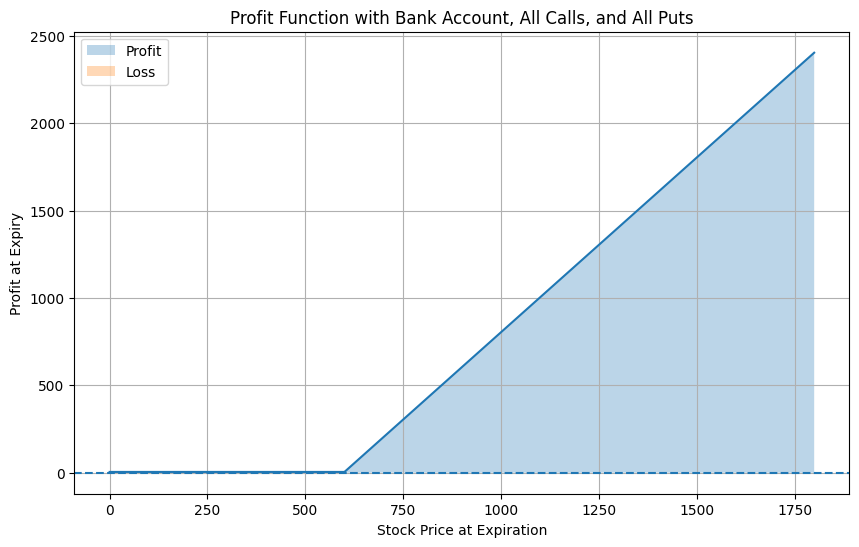

In [3]:
# Run the standard interactive arbitrage analysis.
# The returned dictionary is reused by the interval-focused optimization cell below.
results = run_interactive_analysis()

## Optional Cell 4 — Construct a portfolio positive on one or more intervals

Run this cell after the standard arbitrage test has produced the variable `results`.

The standard arbitrage test searches for a portfolio whose terminal profit function satisfies a global no-loss condition. This optional cell solves a second, more localized problem: among globally non-negative portfolios, it tries to construct one that is strictly positive on a user-specified set

$$
A = A_1 \cup A_2 \cup \cdots \cup A_q.
$$

The user first gives the number of intervals. Then, for each interval, the user gives a left endpoint \(a_j\) and a right endpoint \(b_j\). The right endpoint may be finite, producing

$$
A_j = (a_j,b_j),
$$

or it may be infinite, producing

$$
A_j = (a_j,+\infty).
$$

For a finite interval \(A_j=(a_j,b_j)\), the certificate points are

$$
a_j,\quad b_j,\quad \text{and all option strikes }K_i\text{ such that }a_j<K_i<b_j.
$$

For an unbounded interval \(A_j=(a_j,+\infty)\), there is no finite right endpoint. The certificate points are therefore

$$
a_j,\quad \text{and all option strikes }K_i\text{ such that }K_i>a_j.
$$

The right tail is handled separately. Since the portfolio payoff is piecewise affine in \(S_T=x\), after the largest option strike its slope is constant. The cell imposes the tail-slope guard

$$
\lim_{x\to+\infty}\Pi'(x)
=
\text{net shares}
+
\text{net calls}
\geq 0.
$$

Therefore, for an interval \((a,+\infty)\), positivity at \(a\), positivity at all later strikes, and a non-negative right-tail slope certify positivity on the entire unbounded interval.

Let \(T\) be the union of all finite certificate points generated by the selected intervals. The cell introduces one non-negative variable \(D_y\) for every \(y\in T\), and solves

$$
\max \sum_{y\in T} D_y
$$

subject to

$$
\Pi(x)\geq 0
\qquad \text{for every }x\geq 0,
$$

and

$$
\Pi(y)\geq D_y,
\qquad
D_y\geq 0,
\qquad
y\in T.
$$

If every returned \(D_y\) is strictly positive up to numerical tolerance, then the returned portfolio is a certificate of strict positivity on all selected intervals. If at least one \(D_y\) is zero, the portfolio is still globally non-negative, but the cell has not certified strict positivity on the full union of intervals.


How many intervals do you want to use? 1

Interval A_1.
Use a finite right endpoint, e.g. 150, or type inf for +infty.
Enter the left endpoint a_1: 0
Enter the right endpoint b_1: 30

Focused multi-interval arbitrage result
Solver status: 0
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Selected intervals:
  - A_1 = (0.000000, 30.000000)
Number of finite certificate points: 2
Maximized sum D = 24.98303565

Portfolio table
+-------------------+--------------+-----------------------------------------+------------------+
|       Asset       |  Qty/Amount  |                Unit/Info                | Initial Cashflow |
+-------------------+--------------+-----------------------------------------+------------------+
| TSLA (Net Shares) |   1.978647   | buy@ask=379.780189, sell@bid=372.259789 |    751.450923    |
|    Bank account   | -1165.752923 |            g=(1+r)^T=1.018387           |   -1165.752923   |
+-------------------+--------------+--------------

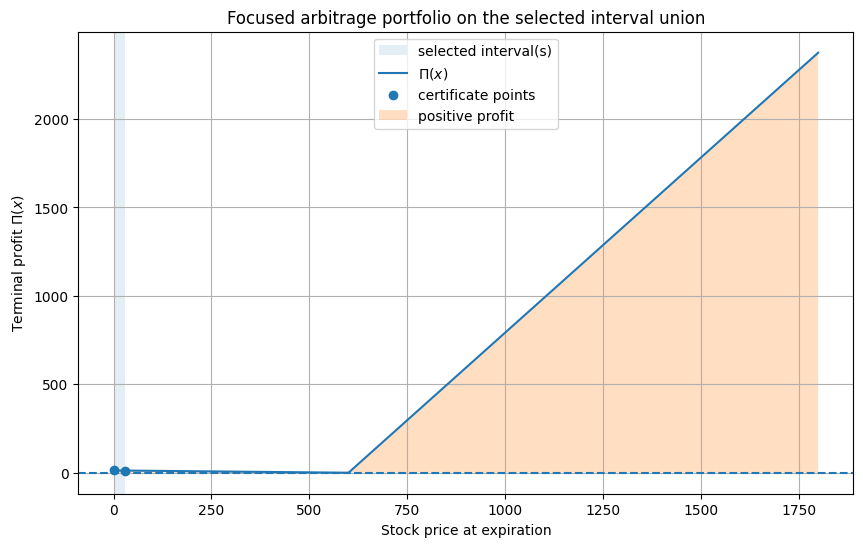

In [4]:
# =============================================================================
# Cell 4 - Construct an arbitrage portfolio positive on one or more intervals
# =============================================================================
#
# Run this cell after:
#     results = run_interactive_analysis()
#
# Mathematical goal:
#     The user provides q intervals A_j. Each interval may be finite,
#     A_j=(a_j,b_j), or unbounded, A_j=(a_j,+infty).
#
#     The cell searches for a portfolio whose terminal profit Pi(x) is globally
#     non-negative on R_+ and positive at all certificate points generated by the
#     selected intervals.
#
# Certificate points:
#     For A_j=(a_j,b_j):
#         a_j, b_j, and all option strikes K_i with a_j < K_i < b_j.
#
#     For A_j=(a_j,+infty):
#         a_j and all option strikes K_i with K_i > a_j.
#         There is no D-variable at +infty. Instead, the model enforces the
#         non-negative right-tail slope of Pi(x).
#
# MILP target constraints:
#     Pi(y) >= D_y for every certificate point y,
#     D_y >= 0.
#
# Objective:
#     maximize sum_y D_y.
#
# Global no-loss constraints:
#     Pi(x) >= 0 for every x >= 0. Because Pi is piecewise affine, this is
#     enforced by checking all breakpoints, all finite certificate points, and
#     one right-tail anchor, together with a non-negative tail-slope guard.
#

def _focused_profit_at_expiry(y, portfolio_x, result, config):
    """Evaluate Pi(y) for the focused interval portfolio."""
    row = _payoff_row(
        float(y),
        result["call_strikes"],
        result["put_strikes"],
        result["bank_growth"],
    )
    # row[:-1] removes the auxiliary z coefficient used in the standard MILP.
    return float(np.dot(row[:-1], portfolio_x) - float(config.initial_capital))


def _parse_finite_left_endpoint(raw_text, interval_number):
    """Parse a finite left endpoint a_j."""
    text = str(raw_text).strip().lower().replace(",", ".")
    try:
        value = float(text)
    except ValueError as exc:
        raise ValueError(
            f"Interval {interval_number}: the left endpoint must be a finite number."
        ) from exc

    if not np.isfinite(value):
        raise ValueError(
            f"Interval {interval_number}: the left endpoint must be finite."
        )
    if value < 0:
        raise ValueError(
            f"Interval {interval_number}: the left endpoint must satisfy a >= 0."
        )
    return float(value)


def _parse_right_endpoint(raw_text, interval_number):
    """
    Parse a right endpoint b_j.

    Accepted infinite inputs include:
        inf, +inf, infinity, +infinity, infty, +infty, oo, +oo, ∞, +∞.
    """
    text = str(raw_text).strip().lower().replace(",", ".")
    infinite_tokens = {
        "inf", "+inf",
        "infinity", "+infinity",
        "infty", "+infty",
        "oo", "+oo",
        "∞", "+∞",
    }

    if text in infinite_tokens:
        return float("inf")

    try:
        value = float(text)
    except ValueError as exc:
        raise ValueError(
            f"Interval {interval_number}: the right endpoint must be a number or +infty."
        ) from exc

    if value < 0:
        raise ValueError(
            f"Interval {interval_number}: the right endpoint must satisfy b >= 0."
        )
    return float(value)


def _read_positive_integer(prompt):
    """Read a positive integer from the notebook prompt."""
    raw = input(prompt).strip()
    try:
        value = int(raw)
    except ValueError as exc:
        raise ValueError("The number of intervals must be a positive integer.") from exc

    if value <= 0:
        raise ValueError("The number of intervals must be at least 1.")
    return value


def _read_intervals_interactively():
    """Ask the user for the number of intervals and then for each interval."""
    q = _read_positive_integer("How many intervals do you want to use? ")

    intervals = []
    for j in range(1, q + 1):
        print("\nInterval A_{}.".format(j))
        print("Use a finite right endpoint, e.g. 150, or type inf for +infty.")

        a_raw = input("Enter the left endpoint a_{}: ".format(j))
        b_raw = input("Enter the right endpoint b_{}: ".format(j))

        a = _parse_finite_left_endpoint(a_raw, j)
        b = _parse_right_endpoint(b_raw, j)

        if np.isfinite(b) and not a < b:
            raise ValueError(
                f"Interval {j}: a finite interval must satisfy a < b."
            )

        if np.isinf(b):
            intervals.append({
                "index": j,
                "a": float(a),
                "b": float("inf"),
                "unbounded": True,
            })
        else:
            intervals.append({
                "index": j,
                "a": float(a),
                "b": float(b),
                "unbounded": False,
            })

    return intervals


def _format_interval(interval):
    """Return a readable label for one interval."""
    a = float(interval["a"])
    if interval["unbounded"]:
        return "A_{} = ({:.6f}, +infty)".format(interval["index"], a)
    return "A_{} = ({:.6f}, {:.6f})".format(
        interval["index"],
        a,
        float(interval["b"]),
    )


def _make_unique_certificate_points(intervals, all_strikes):
    """
    Build the finite certificate set T.

    The same point may be generated by more than one interval. The MILP should
    contain only one D-variable per distinct finite point, so this function
    deduplicates points while preserving explanatory labels.
    """
    point_sources = {}

    def add_point(value, source):
        key = round(float(value), 12)
        if key not in point_sources:
            point_sources[key] = {
                "value": float(value),
                "sources": [],
            }
        point_sources[key]["sources"].append(source)

    for interval in intervals:
        j = int(interval["index"])
        a = float(interval["a"])
        b = float(interval["b"])

        add_point(a, "A_{} left endpoint".format(j))

        if interval["unbounded"]:
            strikes_inside = all_strikes[all_strikes > a]
        else:
            add_point(b, "A_{} right endpoint".format(j))
            strikes_inside = all_strikes[(all_strikes > a) & (all_strikes < b)]

        for strike in strikes_inside:
            add_point(float(strike), "A_{} strike".format(j))

    items = sorted(point_sources.values(), key=lambda item: item["value"])
    target_points = np.array([item["value"] for item in items], dtype=float)
    target_labels = [
        "x_{}: {}".format(k + 1, "; ".join(item["sources"]))
        for k, item in enumerate(items)
    ]

    return target_points, target_labels


def _interval_contains_point(interval, x, tolerance=1e-10):
    """Check whether x belongs to the closed certificate version of the interval."""
    a = float(interval["a"])
    if interval["unbounded"]:
        return x >= a - tolerance

    b = float(interval["b"])
    return (x >= a - tolerance) and (x <= b + tolerance)


def _print_focused_portfolio_tables(focused_result, config):
    """Print the portfolio, option positions, and interval-positivity table."""
    print_portfolio_tables(focused_result, config)

    point_rows = []
    portfolio_x = focused_result["solution"]
    D_values = focused_result["D_values"]

    for label, y, d in zip(
        focused_result["target_labels"],
        focused_result["target_points"],
        D_values,
    ):
        pi_y = _focused_profit_at_expiry(y, portfolio_x, focused_result, config)
        point_rows.append({
            "Point": label,
            "S_T": float(y),
            "D": float(d),
            "Pi(S_T)": float(pi_y),
        })

    print("\n" + "=" * 78)
    print("Interval positivity constraints")
    print("=" * 78)

    if PrettyTable is not None:
        tb = PrettyTable()
        tb.field_names = ["Point", "S_T", "D", "Pi(S_T)"]
        tb.align["Point"] = "l"
        for row in point_rows:
            tb.add_row([
                row["Point"],
                round(row["S_T"], 6),
                round(row["D"], 8),
                round(row["Pi(S_T)"], 8),
            ])
        print(tb)
    else:
        display(pd.DataFrame(point_rows))


def _plot_focused_profit_function(focused_result, config):
    """Plot Pi(x) for the focused multi-interval portfolio."""
    intervals = focused_result["intervals"]
    finite_right_endpoints = [
        float(interval["b"])
        for interval in intervals
        if not interval["unbounded"]
    ]

    max_interval_endpoint = max(finite_right_endpoints) if finite_right_endpoints else 0.0
    max_target = (
        float(np.max(focused_result["target_points"]))
        if len(focused_result["target_points"])
        else 0.0
    )

    y_max = max(
        float(focused_result["S_high"]),
        float(focused_result["spot"]) * 1.5,
        max_interval_endpoint * 1.25,
        max_target * 1.25,
        1.0,
    )

    y_vals = np.linspace(0.0, y_max, int(config.plot_points))
    portfolio_x = focused_result["solution"]
    profits = np.array([
        _focused_profit_at_expiry(y, portfolio_x, focused_result, config)
        for y in y_vals
    ])

    fig = plt.figure(figsize=(10, 6))
    ax = fig.gca()

    # Shade the selected intervals in the displayed plotting window.
    used_interval_label = False
    for interval in intervals:
        left = float(interval["a"])
        right = y_max if interval["unbounded"] else min(float(interval["b"]), y_max)
        if right > 0 and left < y_max:
            ax.axvspan(
                max(left, 0.0),
                right,
                alpha=0.12,
                label="selected interval(s)" if not used_interval_label else None,
            )
            used_interval_label = True

    ax.plot(y_vals, profits, label=r"$\Pi(x)$")
    ax.axhline(0.0, linewidth=1.5, linestyle="--")

    target_points = focused_result["target_points"]
    if len(target_points):
        target_profits = np.array([
            _focused_profit_at_expiry(y, portfolio_x, focused_result, config)
            for y in target_points
        ])
        ax.scatter(target_points, target_profits, zorder=3, label="certificate points")

    ax.fill_between(
        y_vals,
        profits,
        0.0,
        where=(profits > 0.0),
        alpha=0.25,
        label="positive profit",
    )

    ax.set_xlabel("Stock price at expiration")
    ax.set_ylabel(r"Terminal profit $\Pi(x)$")
    ax.set_title("Focused arbitrage portfolio on the selected interval union")
    ax.grid(True)
    ax.legend()
    plt.show()


def build_and_solve_multi_interval_positive_arbitrage(results, intervals):
    """
    Build and solve the multi-interval focused MILP.

    Parameters
    ----------
    results:
        Output dictionary returned by run_interactive_analysis().
    intervals:
        List of dictionaries with keys:
            index, a, b, unbounded.

    Returns
    -------
    Dictionary with the selected portfolio, D-values, certificate points,
    solver status, and all data needed for plotting.
    """
    if results is None:
        raise RuntimeError("Run results = run_interactive_analysis() before this cell.")

    if not intervals:
        raise ValueError("At least one interval is required.")

    config = results["config"]

    call_strikes = np.asarray(results["call_strikes"], dtype=float)
    put_strikes = np.asarray(results["put_strikes"], dtype=float)
    call_ask = np.asarray(results["call_ask"], dtype=float)
    call_bid = np.asarray(results["call_bid"], dtype=float)
    put_ask = np.asarray(results["put_ask"], dtype=float)
    put_bid = np.asarray(results["put_bid"], dtype=float)

    m = len(call_strikes)
    n = len(put_strikes)

    all_strikes = np.unique(np.concatenate([call_strikes, put_strikes]))
    target_points, target_labels = _make_unique_certificate_points(intervals, all_strikes)

    if len(target_points) == 0:
        raise RuntimeError("No finite certificate points were generated.")

    # Portfolio variables are the standard variables except the auxiliary z:
    # [call_buy, call_sell, put_buy, put_sell, share_buy, share_sell, bank].
    old_z_idx = int(results["z_idx"])
    n_portfolio = old_z_idx

    share_buy_idx = int(results["share_buy_idx"])
    share_sell_idx = int(results["share_sell_idx"])
    bank_idx = int(results["bank_idx"])

    n_targets = len(target_points)
    D_start = n_portfolio
    L = n_portfolio + n_targets

    V = float(config.initial_capital)

    def portfolio_coeff(y):
        return _payoff_row(
            float(y),
            call_strikes,
            put_strikes,
            float(results["bank_growth"]),
        )[:-1]

    finite_endpoints = []
    for interval in intervals:
        finite_endpoints.append(float(interval["a"]))
        if not interval["unbounded"]:
            finite_endpoints.append(float(interval["b"]))

    finite_endpoints = np.array(finite_endpoints, dtype=float)

    # For piecewise-affine non-negativity on R_+, check all breakpoints,
    # all finite interval endpoints, all target points, and a right-tail anchor.
    base_grid = np.unique(np.concatenate([
        np.array([0.0], dtype=float),
        all_strikes,
        finite_endpoints,
        target_points,
    ]))

    max_reference = max(
        float(results["spot"]),
        float(base_grid.max()) if len(base_grid) else 1.0,
        1.0,
    )
    S_high = max(
        float(config.high_price_multiplier) * max_reference,
        float(results.get("S_high", 0.0)),
        max_reference,
    )

    nonneg_grid = np.unique(np.append(base_grid, S_high))

    rows = []
    lb = []
    ub = []

    # Pi(x) >= 0 for every x >= 0.
    # It is enough to impose Pi(x) >= 0 on nonneg_grid plus tail slope >= 0.
    for y in nonneg_grid:
        row = np.zeros(L)
        row[:n_portfolio] = portfolio_coeff(y)
        rows.append(row)
        lb.append(V)
        ub.append(np.inf)

    # Pi(target_j) >= D_j, with D_j >= 0.
    for j, y in enumerate(target_points):
        row = np.zeros(L)
        row[:n_portfolio] = portfolio_coeff(y)
        row[D_start + j] = -1.0
        rows.append(row)
        lb.append(V)
        ub.append(np.inf)

    # Tail-slope guard for S_T -> infinity:
    # slope = net shares + long calls - short calls >= 0.
    row = np.zeros(L)
    row[0:m] = 1.0
    row[m:2*m] = -1.0
    row[share_buy_idx] = 1.0
    row[share_sell_idx] = -1.0
    rows.append(row)
    lb.append(0.0)
    ub.append(np.inf)

    # Initial budget equality.
    row = np.zeros(L)
    row[0:m] = call_ask
    row[m:2*m] = -call_bid
    row[2*m:2*m+n] = put_ask
    row[2*m+n:2*m+2*n] = -put_bid
    row[share_buy_idx] = float(results["stock_ask"])
    row[share_sell_idx] = -float(results["stock_bid"])
    row[bank_idx] = 1.0
    rows.append(row)
    lb.append(V)
    ub.append(V)

    # Total option-position limits.
    row = np.zeros(L)
    row[0:m] = 1.0
    rows.append(row)
    lb.append(-np.inf)
    ub.append(float(config.max_total_call_options_to_buy))

    row = np.zeros(L)
    row[m:2*m] = 1.0
    rows.append(row)
    lb.append(-np.inf)
    ub.append(float(config.max_total_call_options_to_sell))

    row = np.zeros(L)
    row[2*m:2*m+n] = 1.0
    rows.append(row)
    lb.append(-np.inf)
    ub.append(float(config.max_total_put_options_to_buy))

    row = np.zeros(L)
    row[2*m+n:2*m+2*n] = 1.0
    rows.append(row)
    lb.append(-np.inf)
    ub.append(float(config.max_total_put_options_to_sell))

    A = np.vstack(rows)
    constraints = LinearConstraint(A, np.asarray(lb), np.asarray(ub))

    lower = np.zeros(L)
    upper = np.full(L, np.inf)

    # Per-instrument option bounds.
    upper[0:m] = float(config.max_call_options_to_buy_per_contract)
    upper[m:2*m] = float(config.max_call_options_to_sell_per_contract)
    upper[2*m:2*m+n] = float(config.max_put_options_to_buy_per_contract)
    upper[2*m+n:2*m+2*n] = float(config.max_put_options_to_sell_per_contract)

    # Share buy/sell bounds.
    upper[share_buy_idx] = float(config.max_shares_to_buy)
    upper[share_sell_idx] = float(config.max_shares_to_sell)

    # Bank-account bounds.
    lower[bank_idx] = -float(config.max_borrow_limit)
    upper[bank_idx] = float(config.max_deposit_limit)

    # D variables.
    lower[D_start:D_start+n_targets] = 0.0
    upper[D_start:D_start+n_targets] = np.inf

    bounds = Bounds(lower, upper)

    # Options are integer. Stock, bank, and D variables are continuous.
    integrality = np.ones(L, dtype=int)
    integrality[share_buy_idx] = 0
    integrality[share_sell_idx] = 0
    integrality[bank_idx] = 0
    integrality[D_start:D_start+n_targets] = 0

    # scipy.optimize.milp minimizes, so maximize sum(D_j) by minimizing -sum(D_j).
    c = np.zeros(L)
    c[D_start:D_start+n_targets] = -1.0

    res = milp(c=c, constraints=constraints, integrality=integrality, bounds=bounds)

    if res.x is None:
        raise RuntimeError(
            f"Focused MILP did not return a solution. "
            f"Status={res.status}, message={res.message}"
        )

    portfolio_x = np.asarray(res.x[:n_portfolio], dtype=float)
    D_values = np.asarray(res.x[D_start:D_start+n_targets], dtype=float)

    focused_result = {
        "solution": portfolio_x,
        "status": res.status,
        "message": res.message,
        "objective_sum_D": float(np.sum(D_values)),
        "D_values": D_values,
        "target_points": target_points,
        "target_labels": target_labels,
        "intervals": intervals,
        "call_strikes": call_strikes,
        "put_strikes": put_strikes,
        "all_strikes": all_strikes,
        "call_ask": call_ask,
        "call_bid": call_bid,
        "put_ask": put_ask,
        "put_bid": put_bid,
        "calls_table": results.get("calls_table", results.get("calls")),
        "puts_table": results.get("puts_table", results.get("puts")),
        "bank_growth": float(results["bank_growth"]),
        "grid": nonneg_grid,
        "S_high": S_high,
        "share_buy_idx": share_buy_idx,
        "share_sell_idx": share_sell_idx,
        "bank_idx": bank_idx,
        "stock_bid": float(results["stock_bid"]),
        "stock_ask": float(results["stock_ask"]),
        "spot": float(results["spot"]),
        "T": float(results["T"]),
        "config": config,
    }

    return focused_result


def build_and_solve_interval_positive_arbitrage(results, a, b):
    """
    Backward-compatible wrapper for a single interval.

    The right endpoint b may be finite or +infty.
    """
    interval = {
        "index": 1,
        "a": _parse_finite_left_endpoint(a, 1),
        "b": _parse_right_endpoint(b, 1),
        "unbounded": bool(np.isinf(_parse_right_endpoint(b, 1))),
    }
    if np.isfinite(interval["b"]) and not interval["a"] < interval["b"]:
        raise ValueError("The interval must satisfy a < b.")
    return build_and_solve_multi_interval_positive_arbitrage(results, [interval])


# -----------------------------
# Interactive run of the new cell
# -----------------------------

try:
    standard_z = float(results["solution"][int(results["z_idx"])])
    tol = float(results["config"].solver_tolerance)
    if standard_z > tol:
        print("[WARNING] The standard arbitrage test did not find a globally non-negative arbitrage portfolio.")
        print("The focused MILP will still run, but strict positivity on the selected intervals may fail.")
except Exception:
    pass

selected_intervals = _read_intervals_interactively()

focused_results = build_and_solve_multi_interval_positive_arbitrage(
    results,
    selected_intervals,
)

print("\n" + "=" * 78)
print("Focused multi-interval arbitrage result")
print("=" * 78)
print("Solver status:", focused_results["status"])
print("Solver message:", focused_results["message"])

print("\nSelected intervals:")
for interval in focused_results["intervals"]:
    print("  -", _format_interval(interval))

print("Number of finite certificate points:", len(focused_results["target_points"]))
print("Maximized sum D =", round(focused_results["objective_sum_D"], 8))

_print_focused_portfolio_tables(
    focused_results,
    focused_results["config"] if "config" in focused_results else results["config"],
)

tol = float(results["config"].solver_tolerance)
min_D = float(np.min(focused_results["D_values"])) if len(focused_results["D_values"]) else 0.0

print("\n" + "=" * 78)
print("Conclusion for the selected intervals")
print("=" * 78)

if focused_results["objective_sum_D"] <= tol:
    print("[CONCLUSION] No positive payoff was found at the selected certificate points.")
    print("The MILP found only D_y = 0 within the imposed bounds.")
elif min_D > tol:
    print("[CONCLUSION] The returned portfolio is positive at every finite certificate point.")
    print("Since Pi is piecewise affine, this certifies positivity on every selected finite interval.")
    print("For every selected interval of the form (a,+infty), the certificate also uses the non-negative tail-slope guard.")
else:
    zero_like = [
        (label, point, value)
        for label, point, value in zip(
            focused_results["target_labels"],
            focused_results["target_points"],
            focused_results["D_values"],
        )
        if float(value) <= tol
    ]

    print("[CONCLUSION] The returned portfolio is globally non-negative and positive at least at one selected point,")
    print("but it is not positive at every finite certificate point. Some D-values are zero.")
    print("Zero or near-zero certificate points:")
    for label, point, value in zero_like:
        print("  - {} at S_T = {:.6f}, D = {:.8f}".format(label, float(point), float(value)))
    print("For a stricter certificate, replace the objective by maximizing a common lower bound t.")

_plot_focused_profit_function(focused_results, results["config"])


## Optional Cell 5 — Run with advanced prompts

This optional cell reruns the same arbitrage-search workflow, but with additional user-controlled model inputs.

The standard workflow fixes several modelling choices at their default values. The advanced workflow allows the user to choose parameters such as the risk-free rate, the initial capital, and whether to use `lastPrice` as a frictionless quote before the artificial perturbation.

Mathematically, these choices affect the budget equation and the terminal bank payoff. For example, the bank account contributes

$$
B(1+r)^T
$$

to the terminal payoff, while its initial contribution to the budget equation is

$$
B.
$$

Changing $r$ or $T$ therefore changes the slope-free part of $\Pi(x)$, while changing bid-ask assumptions changes the feasible set of self-financing portfolios.

This cell is commented out by default so that GitHub readers can see the advanced option without accidentally rerunning a second analysis.

In [5]:
# Uncomment and run this cell if you want advanced prompts as well.
# The advanced run exposes additional modelling parameters such as the risk-free rate,
# initial capital, quote convention, stock spread, and absolute perturbation.
# results = run_interactive_analysis(ask_advanced_settings=True)

## Optional Cell 6 — Inspect the exact option quotes used

After the interactive analysis has finished, this optional cell displays the effective option quotes that were passed to the MILP.

This is useful for auditing the model because each call and each put appears as a separate instrument. The implementation does not require a call and a put to share the same strike. If the available call strikes are

$$
K_1^C,\ldots,K_m^C
$$

and the available put strikes are

$$
K_1^P,\ldots,K_n^P,
$$

then the model contains $m+n$ independent option instruments, before separating each one into long and short decision variables.

Displaying the effective quotes is especially helpful when the notebook is uploaded to GitHub after being run: the reader can verify which market data produced the portfolio tables and payoff plots shown in the outputs.

In [6]:
# Uncomment after running the analysis if you want to inspect the effective quotes.
# This audit table shows the call and put prices that were actually passed to the MILP.
# display_used_quotes(results["calls"], results["puts"], max_rows=50)